<a href="https://colab.research.google.com/github/simplyshree/SeqTrainer/blob/issue-3-all-model-baselines/dnabert2_shared_split_benchmark_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DNABERT2 Shared-Split Promoter Benchmark

This notebook uses the same simple execution pattern as `dna-bert/Colab_test_dnabert2.ipynb`: a dedicated Conda environment, explicit package versions, one visible model-run command, and output analysis in later cells.

**Fair-comparison contract**
- exact CNN train/validation/test CSV files
- identical binary labels and seed `42`
- native DNABERT2 BPE tokenization
- checkpoint and probability threshold selected on validation MCC only
- test split used once for final reporting
- shared metrics and artifact files

This notebook runs the frozen DNABERT2 encoder baseline first. It trains only a small classification head over cached DNABERT2 embeddings, making it more stable and less expensive than full fine-tuning.


## 1. Install Conda in Colab

Choose **Runtime > Change runtime type > T4 GPU**, then run this cell. CondaColab restarts the runtime automatically. After Colab reconnects, continue from Step 2; do not rerun this cell.


In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()


✨🍰✨ Everything looks OK!


## 2. Clone SeqTrainer and create the DNABERT2 environment

This follows the working test notebook but uses Python 3.10 and a modern PyTorch build required by the current SeqTrainer package. `transformers==4.30.2` is pinned because it matches the original working DNABERT2 notebook and avoids the Transformers 5.x incompatibilities encountered earlier.


In [2]:
from pathlib import Path
import os
import random
import subprocess
import sys

SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

REPO_URL = "https://github.com/simplyshree/SeqTrainer.git"
REVISION = os.environ.get("SEQTRAINER_REVISION", "issue-3-all-model-baselines")
REPO_DIR = Path("/content/SeqTrainer")
ENV_NAME = "dna"

if REPO_DIR.exists():
    subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin", REVISION], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "checkout", REVISION], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", REVISION], check=True)
else:
    subprocess.run(["git", "clone", "--branch", REVISION, REPO_URL, str(REPO_DIR)], check=True)

existing_envs = subprocess.check_output(["conda", "env", "list"], text=True)
if not any(line.split() and line.split()[0] == ENV_NAME for line in existing_envs.splitlines()):
    subprocess.run(["conda", "create", "-y", "-n", ENV_NAME, "python=3.10", "pip"], check=True)
else:
    print(f"Conda environment {ENV_NAME!r} already exists")

subprocess.run([
    "conda", "run", "-n", ENV_NAME, "python", "-m", "pip", "install", "-q",
    "torch==2.2.2", "--index-url", "https://download.pytorch.org/whl/cu121",
], check=True)
# The original successful notebook had no usable Triton installation, so
# DNABERT2 selected its standard PyTorch attention path. Reproduce that
# stable behavior instead of using its old incompatible Triton kernel.
subprocess.run([
    "conda", "run", "-n", ENV_NAME, "python", "-m", "pip", "uninstall", "-y", "triton",
], check=False)
subprocess.run([
    "conda", "run", "-n", ENV_NAME, "python", "-m", "pip", "install", "-q", "--force-reinstall",
    "transformers==4.29.2", "einops==0.6.1", "scikit-learn==1.3.2", "pandas==2.0.3", "numpy==1.24.4",
], check=True)
subprocess.run([
    "conda", "run", "-n", ENV_NAME, "python", "-m", "pip", "install", "-q", "-e", str(REPO_DIR),
], check=True)

os.chdir(REPO_DIR)
commit = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
print("Repository:", REPO_DIR)
print("Revision:", REVISION)
print("Commit:", commit)


Conda environment 'dna' already exists
Repository: /content/SeqTrainer
Revision: issue-3-all-model-baselines
Commit: 206ae6616eeabe426473a83a3d42a3d3f7b73f64


## 3. Verify the isolated environment

This is the equivalent of the environment-check cells in the working test notebook. The benchmark must use the `dna` environment shown here, not Colab's default Python packages.


In [3]:
CHECK_SCRIPT = REPO_DIR / "check_dnabert2_env.py"
CHECK_SCRIPT.write_text("""
import sys
import numpy
import pandas
import sklearn
import torch
import transformers
import importlib.util
import seqtrainer

print('python:', sys.version.split()[0])
print('numpy:', numpy.__version__)
print('pandas:', pandas.__version__)
print('scikit-learn:', sklearn.__version__)
print('torch:', torch.__version__)
print('transformers:', transformers.__version__)
print('triton installed:', importlib.util.find_spec('triton') is not None)
print('seqtrainer:', seqtrainer.__file__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))
else:
    raise RuntimeError('CUDA is unavailable. Select a Colab GPU runtime before running the full benchmark.')
""", encoding="utf-8")
subprocess.run(["conda", "run", "--no-capture-output", "-n", ENV_NAME, "python", str(CHECK_SCRIPT)], check=True)


CompletedProcess(args=['conda', 'run', '--no-capture-output', '-n', 'dna', 'python', '/content/SeqTrainer/check_dnabert2_env.py'], returncode=0)

## 4. Run a one-sequence DNABERT2 preflight

This mirrors the successful model-loading test in the original notebook. It uses the actual SeqTrainer loader and standard PyTorch attention fallback. Continue only if it prints a pooled embedding shape of `(1, 768)`.


In [4]:
PREFLIGHT_SCRIPT = REPO_DIR / "check_dnabert2_model.py"
PREFLIGHT_SCRIPT.write_text("""
import torch
from seqtrainer.torch.dnabert2_benchmark import _load_huggingface_dnabert2, _last_hidden_state, _pool_hidden_states

device = torch.device('cuda')
tokenizer, encoder = _load_huggingface_dnabert2(
    'zhihan1996/DNABERT-2-117M',
    device=device,
    trust_remote_code=True,
    local_files_only=False,
    disable_flash_attention=True,
)
sequence = 'ACGTAGCATCGGATCTATCTATCGACACTTGGTTATCGATCTACGAGCATCTCGTTAGC'
batch = tokenizer(sequence, padding=True, truncation=True, max_length=104, return_tensors='pt')
batch = {key: value.to(device) for key, value in batch.items()}
with torch.no_grad():
    outputs = encoder(**batch)
    pooled = _pool_hidden_states(_last_hidden_state(outputs), batch['attention_mask'], 'mean')
print('Model loaded successfully')
print('Pooled embedding shape:', tuple(pooled.shape))
print('Device:', pooled.device)
""", encoding="utf-8")
preflight = subprocess.run(
    ["conda", "run", "-n", ENV_NAME, "python", str(PREFLIGHT_SCRIPT)],
    text=True,
    capture_output=True,
)
print("===== DNABERT2 PREFLIGHT STDOUT =====")
print(preflight.stdout or "<empty>")
print("===== DNABERT2 PREFLIGHT STDERR =====")
print(preflight.stderr or "<empty>")
if preflight.returncode != 0:
    raise RuntimeError(
        "DNABERT2 preflight failed. The complete model-loading error is printed above. "
        "Rerun Step 2 once to repair the pinned environment, then rerun Steps 3 and 4."
    )


===== DNABERT2 PREFLIGHT STDOUT =====
Model loaded successfully
Pooled embedding shape: (1, 768)
Device: cuda:0


===== DNABERT2 PREFLIGHT STDERR =====
/usr/local/envs/dna/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- configuration_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- bert_padding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


## 5. Materialize the exact CNN split files

The repository contains the three predefined CSV files in a ZIP archive. Extracting that archive guarantees that CNN and DNABERT2 receive the same rows. No new random split is generated here.


In [5]:
import zipfile

ARCHIVE = REPO_DIR / "data" / "data_DNABERT" / "promoter_classification_DNABERT.zip"
DATA_DIR = REPO_DIR / "data" / "promoter_classification"
DATA_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_FILES = {
    "train": "train_EP_DNA_BERT2_genomic_order.csv",
    "validation": "eval_EP_DNA_BERT2_genomic_order.csv",
    "test": "test_EP_DNA_BERT2_genomic_order.csv",
}

missing = [name for name in SPLIT_FILES.values() if not (DATA_DIR / name).exists()]
if missing:
    if not ARCHIVE.exists():
        raise FileNotFoundError(f"Bundled split archive not found: {ARCHIVE}")
    with zipfile.ZipFile(ARCHIVE) as archive:
        for name in missing:
            with archive.open(name) as source, (DATA_DIR / name).open("wb") as target:
                target.write(source.read())
            print("Extracted:", name)
else:
    print("Shared split CSVs already exist")

for split, name in SPLIT_FILES.items():
    print(split, DATA_DIR / name, (DATA_DIR / name).stat().st_size, "bytes")

Extracted: train_EP_DNA_BERT2_genomic_order.csv
Extracted: eval_EP_DNA_BERT2_genomic_order.csv
Extracted: test_EP_DNA_BERT2_genomic_order.csv
train /content/SeqTrainer/data/promoter_classification/train_EP_DNA_BERT2_genomic_order.csv 33769302 bytes
validation /content/SeqTrainer/data/promoter_classification/eval_EP_DNA_BERT2_genomic_order.csv 4832320 bytes
test /content/SeqTrainer/data/promoter_classification/test_EP_DNA_BERT2_genomic_order.csv 9642187 bytes


## 6. Audit the split contract

This cell checks schema, duplicate sequences, class balance, and sequence lengths before model execution. The test set is inspected descriptively but is not used for selecting a model or threshold.


In [8]:
import pandas as pd

frames = {}
audit_rows = []
for split, name in SPLIT_FILES.items():
    frame = pd.read_csv(DATA_DIR / name)
    required = {"sequence", "label"}
    if missing_columns := required.difference(frame.columns):
        raise ValueError(f"{split} is missing columns: {sorted(missing_columns)}")
    frame = frame.copy()
    frame["sequence"] = frame["sequence"].astype(str).str.upper()
    frame["label"] = frame["label"].astype(int)
    if not set(frame["label"].unique()).issubset({0, 1}):
        raise ValueError(f"{split} contains labels outside 0/1")
    frames[split] = frame
    lengths = frame["sequence"].str.len()
    counts = frame["label"].value_counts().to_dict()
    audit_rows.append({
        "split": split,
        "rows": len(frame),
        "negative": int(counts.get(0, 0)),
        "positive": int(counts.get(1, 0)),
        "positive_fraction": float(frame["label"].mean()),
        "duplicate_sequences": int(frame["sequence"].duplicated().sum()),
        "min_bp": int(lengths.min()),
        "median_bp": float(lengths.median()),
        "max_bp": int(lengths.max()),
    })

audit = pd.DataFrame(audit_rows)
display(audit)

train_sequences = set(frames["train"]["sequence"])
validation_sequences = set(frames["validation"]["sequence"])
test_sequences = set(frames["test"]["sequence"])
print("train/validation sequence overlap:", len(train_sequences & validation_sequences))
print("train/test sequence overlap:", len(train_sequences & test_sequences))
print("validation/test sequence overlap:", len(validation_sequences & test_sequences))

,split,rows,negative,positive,positive_fraction,duplicate_sequences,min_bp,median_bp,max_bp
0,train,136484,68138,68346,0.500762,63,48,244.0,498
1,validation,19498,9758,9740,0.499538,1,48,245.0,470
2,test,38996,19593,19403,0.497564,7,48,244.0,499


train/validation sequence overlap: 23
train/test sequence overlap: 30
validation/test sequence overlap: 4


## 7. Verify the benchmark configuration

The biological inputs and evaluation policy match CNN-v2. DNABERT2-specific optimization settings remain model-appropriate and are recorded transparently.


In [9]:
import tomllib
import pandas as pd

BASE_CONFIG_PATH = REPO_DIR / "config-examples" / "benchmarks" / "dnabert2_frozen.toml"
CONFIG_PATH = REPO_DIR / "outputs" / "configs" / "dnabert2_frozen_colab_t4.toml"
CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)

config_text = BASE_CONFIG_PATH.read_text(encoding="utf-8")
config_text = config_text.replace('precision = "bf16"', 'precision = "float32"')
config_text = config_text.replace(
    'output_dir = "outputs/benchmarks/dnabert2_frozen_ep_genomic_order"',
    'output_dir = "outputs/benchmarks/dnabert2_frozen_ep_genomic_order_colab"',
)
CONFIG_PATH.write_text(config_text, encoding="utf-8")

with CONFIG_PATH.open("rb") as handle:
    raw_config = tomllib.load(handle)

assert raw_config["experiment"]["seed"] == 42
assert raw_config["split"]["seed"] == 42
assert raw_config["training"]["seed"] == 42
assert raw_config["training"]["batch_size"] == 16
assert raw_config["evaluation"]["threshold_strategy"] == "validation_mcc"
assert raw_config["model"]["params"]["mode"] == "frozen_embedding_classifier"
assert raw_config["model"]["params"]["disable_flash_attention"] is True
assert raw_config["dataset"]["split_files"] == {
    "train": "data/promoter_classification/train_EP_DNA_BERT2_genomic_order.csv",
    "validation": "data/promoter_classification/eval_EP_DNA_BERT2_genomic_order.csv",
    "test": "data/promoter_classification/test_EP_DNA_BERT2_genomic_order.csv",
}

display(pd.DataFrame([
    {"setting": "model", "value": raw_config["model"]["name"]},
    {"setting": "mode", "value": raw_config["model"]["params"]["mode"]},
    {"setting": "pooling", "value": raw_config["model"]["params"]["pooling"]},
    {"setting": "source sequence length", "value": raw_config["preprocessing"]["sequence_length"]},
    {"setting": "token max length", "value": raw_config["preprocessing"]["params"]["model_max_length"]},
    {"setting": "T4 extraction batch size", "value": raw_config["training"]["batch_size"]},
    {"setting": "maximum head epochs", "value": raw_config["training"]["max_epochs"]},
    {"setting": "classifier learning rate", "value": raw_config["training"]["learning_rate"]},
    {"setting": "seed", "value": raw_config["training"]["seed"]},
    {"setting": "threshold policy", "value": raw_config["evaluation"]["threshold_strategy"]},
]))
print("Colab config:", CONFIG_PATH)


,setting,value
0,model,zhihan1996/DNABERT-2-117M
1,mode,frozen_embedding_classifier
2,pooling,mean
3,source sequence length,300
4,token max length,104
5,T4 extraction batch size,16
6,maximum head epochs,50
7,classifier learning rate,0.0003
8,seed,42
9,threshold policy,validation_mcc


Colab config: /content/SeqTrainer/outputs/configs/dnabert2_frozen_colab_t4.toml


## 8. Run DNABERT2

Like the working test notebook's shell-script cells, this cell writes one small runner script and executes it inside the `dna` environment. Training progress is printed directly in the notebook. Do not interrupt the embedding extraction step.


In [10]:
RUN_SCRIPT = REPO_DIR / "run_dnabert2_shared_benchmark.py"
RUN_SCRIPT.write_text(f"""
import os
from pathlib import Path

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from seqtrainer.benchmarks.runner import run_benchmark

repo_dir = Path('/content/SeqTrainer')
os.chdir(repo_dir)
config_path = Path({str(CONFIG_PATH)!r})
result = run_benchmark(config_path, base_dir=repo_dir, allow_skip=False)
print('status:', result.status)
print('output_dir:', result.output_dir)
print('test_mcc:', result.metrics['test']['mcc'])
print('test_auprc:', result.metrics['test']['auprc'])
""", encoding="utf-8")

print("Running command:")
print(f"conda run -n {ENV_NAME} python {RUN_SCRIPT}")
print("Embedding extraction can be quiet for several minutes; do not interrupt while GPU memory is active.")
subprocess.run([
    "conda", "run", "--no-capture-output", "-n", ENV_NAME, "python", str(RUN_SCRIPT)
], check=True)

OUTPUT_DIR = REPO_DIR / "outputs" / "benchmarks" / "dnabert2_frozen_ep_genomic_order_colab"
print("Completed output directory:", OUTPUT_DIR)


Running command:
conda run -n dna python /content/SeqTrainer/run_dnabert2_shared_benchmark.py
Embedding extraction can be quiet for several minutes; do not interrupt while GPU memory is active.
Completed output directory: /content/SeqTrainer/outputs/benchmarks/dnabert2_frozen_ep_genomic_order_colab


## 9. View all shared metrics

The same validation-selected threshold is applied to train, validation, and test. The test row is the final held-out result. MCC is the primary metric; AUPRC is the secondary metric.


In [11]:
metrics = pd.read_csv(OUTPUT_DIR / "metrics.csv")
metric_columns = [
    "split", "threshold", "accuracy", "balanced_accuracy", "precision",
    "recall", "f1", "mcc", "sensitivity", "specificity",
    "tn", "fp", "fn", "tp", "auroc", "auprc", "loss",
]
display(metrics[[column for column in metric_columns if column in metrics.columns]])

test_metrics = metrics.loc[metrics["split"] == "test"].iloc[0]
print("Final held-out test MCC:", round(float(test_metrics["mcc"]), 4))
print("Final held-out test AUPRC:", round(float(test_metrics["auprc"]), 4))

,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,sensitivity,specificity,tn,fp,fn,tp,auroc,auprc,loss
0,train,0.50522,0.553017,0.553339,0.593138,0.341966,0.433819,NaN,0.341966,0.764713,52106,16032,44974,23372,0.571109,0.572131,0.689723
1,validation,0.50522,0.555339,0.555141,0.596050,0.340862,0.433703,0.122066,0.340862,0.769420,7508,2250,6420,3320,0.572632,0.573041,0.689663
2,test,0.50522,0.557262,0.556231,0.595158,0.344586,0.436466,0.124165,0.344586,0.767876,15045,4548,12717,6686,0.573813,0.575073,0.689609


Final held-out test MCC: 0.1242
Final held-out test AUPRC: 0.5751


## 10. Plot training history

Falling training loss with rising validation loss indicates overfitting. The best checkpoint is selected from validation MCC rather than from the final epoch.


,epoch,train_loss,validation_loss,validation_mcc,validation_threshold,learning_rate
45,46.0,0.689758,0.689648,0.121978,0.505569,0.000026
46,47.0,0.689734,0.689642,0.121809,0.505250,0.000019
47,48.0,0.689781,0.689638,0.121923,0.505561,0.000013
48,49.0,0.689731,0.689635,0.121667,0.505557,0.000006
49,50.0,0.689717,0.689634,0.121559,0.505555,0.000000


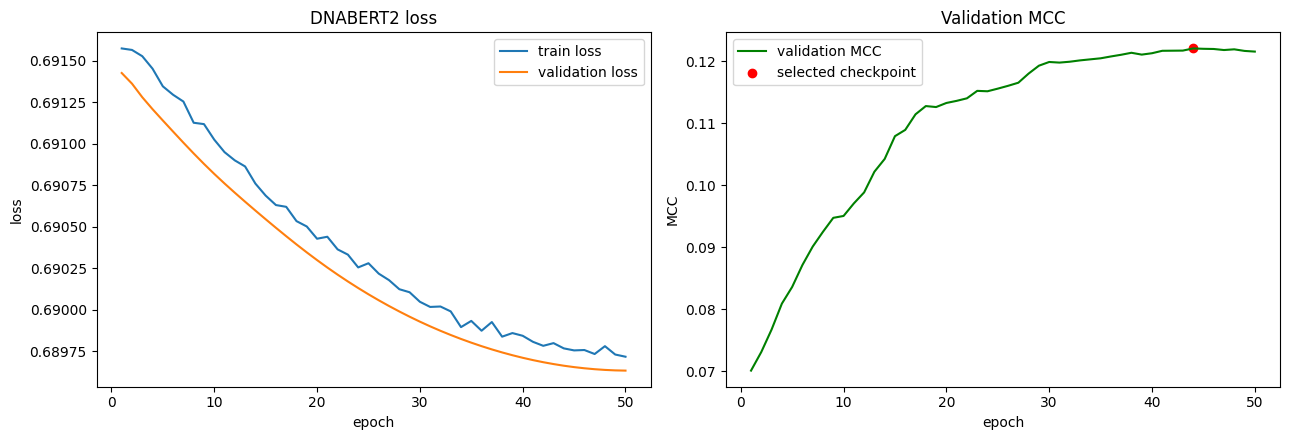

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
history = pd.read_csv(OUTPUT_DIR / "history.csv")
display(history.tail())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history["epoch"], history["train_loss"], label="train loss")
axes[0].plot(history["epoch"], history["validation_loss"], label="validation loss")
axes[0].set(title="DNABERT2 loss", xlabel="epoch", ylabel="loss")
axes[0].legend()

axes[1].plot(history["epoch"], history["validation_mcc"], color="green", label="validation MCC")
best_index = history["validation_mcc"].idxmax()
axes[1].scatter(history.loc[best_index, "epoch"], history.loc[best_index, "validation_mcc"], color="red", label="selected checkpoint")
axes[1].set(title="Validation MCC", xlabel="epoch", ylabel="MCC")
axes[1].legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "training_history.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Plot validation-only threshold selection

This graph explains why the reported threshold may differ from 0.5. Threshold candidates are evaluated using validation labels only. The chosen value is then frozen before test evaluation.


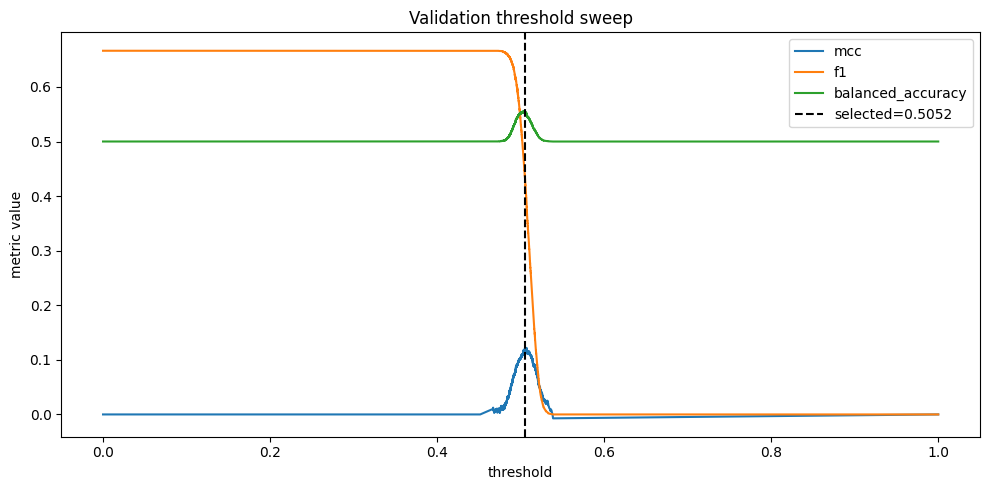

In [14]:
import numpy as np
from sklearn.metrics import balanced_accuracy_score, f1_score, matthews_corrcoef

predictions = pd.read_csv(OUTPUT_DIR / "predictions.csv")
validation_predictions = predictions.loc[predictions["split"] == "validation"].copy()
thresholds = np.unique(np.concatenate(([0.0], validation_predictions["probability"].to_numpy(), [1.0])))
threshold_rows = []
for threshold in thresholds:
    predicted = (validation_predictions["probability"].to_numpy() >= threshold).astype(int)
    labels = validation_predictions["label"].to_numpy()
    threshold_rows.append({
        "threshold": float(threshold),
        "mcc": float(matthews_corrcoef(labels, predicted)),
        "f1": float(f1_score(labels, predicted, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(labels, predicted)),
    })
threshold_sweep = pd.DataFrame(threshold_rows)
selected_threshold = float(validation_predictions["threshold"].iloc[0])

ax = threshold_sweep.plot(x="threshold", y=["mcc", "f1", "balanced_accuracy"], figsize=(10, 5))
ax.axvline(selected_threshold, color="black", linestyle="--", label=f"selected={selected_threshold:.4f}")
ax.set(title="Validation threshold sweep", ylabel="metric value")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "validation_threshold_sweep.png", dpi=160, bbox_inches="tight")
plt.show()

## 12. Confusion matrices and test ROC/PR curves

The confusion matrices show class-specific errors. ROC and precision-recall curves use continuous probabilities; AUPRC is especially important for future imbalanced promoter datasets.


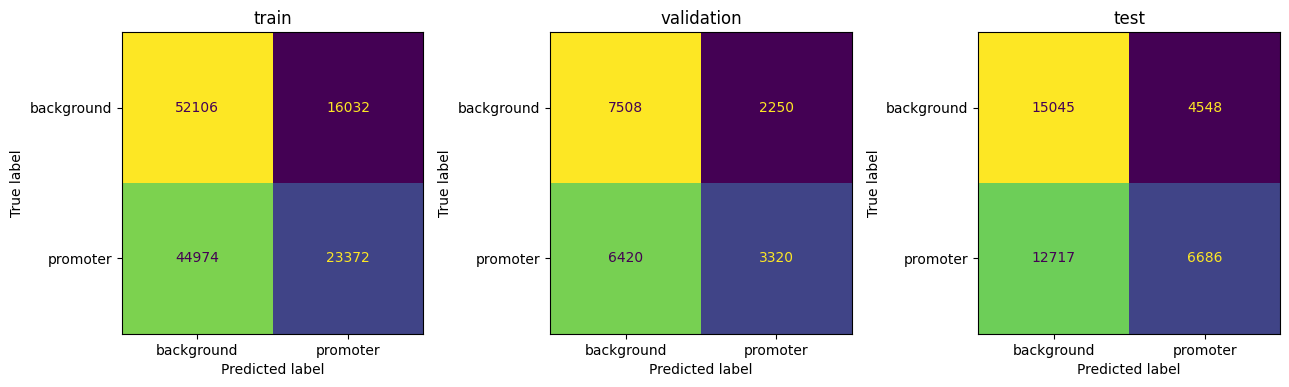

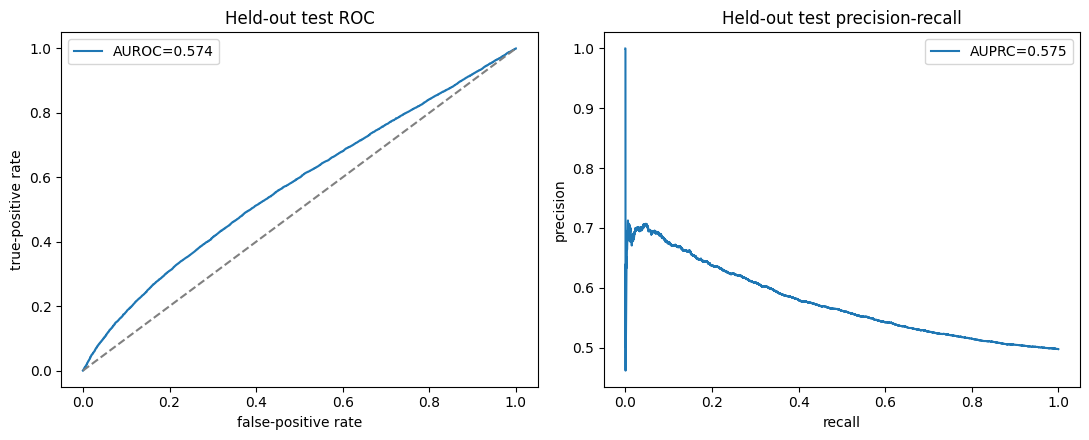

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, auc, precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for axis, split in zip(axes, ["train", "validation", "test"]):
    split_frame = predictions.loc[predictions["split"] == split]
    ConfusionMatrixDisplay.from_predictions(
        split_frame["label"], split_frame["prediction"],
        labels=[0, 1], display_labels=["background", "promoter"],
        colorbar=False, ax=axis,
    )
    axis.set_title(split)
plt.tight_layout()
plt.savefig(PLOT_DIR / "confusion_matrices.png", dpi=160, bbox_inches="tight")
plt.show()

test_predictions = predictions.loc[predictions["split"] == "test"]
y_true = test_predictions["label"].to_numpy()
y_score = test_predictions["probability"].to_numpy()
fpr, tpr, _ = roc_curve(y_true, y_score)
precision, recall, _ = precision_recall_curve(y_true, y_score)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, label=f"AUROC={auc(fpr, tpr):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set(title="Held-out test ROC", xlabel="false-positive rate", ylabel="true-positive rate")
axes[0].legend()
axes[1].plot(recall, precision, label=f"AUPRC={float(test_metrics['auprc']):.3f}")
axes[1].set(title="Held-out test precision-recall", xlabel="recall", ylabel="precision")
axes[1].legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "test_roc_pr_curves.png", dpi=160, bbox_inches="tight")
plt.show()

## 13. Compare with CNN-v2

Run the CNN-v2 notebook on the same checkout or upload its `metrics.csv`. This cell compares held-out test metrics without changing either model's selected threshold.


In [16]:
CNN_METRICS_PATH = REPO_DIR / "outputs" / "benchmarks" / "cnn_v2_regularized_ep_genomic_order" / "metrics.csv"

comparison_metrics = ["mcc", "auprc", "balanced_accuracy", "f1", "precision", "recall", "sensitivity", "specificity", "auroc", "accuracy"]
dnabert_test = metrics.loc[metrics["split"] == "test"].iloc[0]
comparison_rows = [{"model": "DNABERT2 frozen", **{metric: dnabert_test.get(metric) for metric in comparison_metrics}}]

if CNN_METRICS_PATH.exists():
    cnn_metrics = pd.read_csv(CNN_METRICS_PATH)
    cnn_test = cnn_metrics.loc[cnn_metrics["split"] == "test"].iloc[0]
    comparison_rows.append({"model": "CNN-v2", **{metric: cnn_test.get(metric) for metric in comparison_metrics}})
else:
    print("CNN metrics not found at", CNN_METRICS_PATH)
    print("Run CNN-v2 or change CNN_METRICS_PATH to the saved CNN metrics.csv file.")

comparison = pd.DataFrame(comparison_rows)
display(comparison)

if len(comparison) == 2:
    plot_metrics = ["mcc", "auprc", "balanced_accuracy", "f1"]
    comparison.set_index("model")[plot_metrics].T.plot(kind="bar", figsize=(10, 5))
    plt.title("Held-out test comparison")
    plt.ylabel("metric value")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "cnn_v2_dnabert2_test_comparison.png", dpi=160, bbox_inches="tight")
    plt.show()

CNN metrics not found at /content/SeqTrainer/outputs/benchmarks/cnn_v2_regularized_ep_genomic_order/metrics.csv
Run CNN-v2 or change CNN_METRICS_PATH to the saved CNN metrics.csv file.


,model,mcc,auprc,balanced_accuracy,f1,precision,recall,sensitivity,specificity,auroc,accuracy
0,DNABERT2 frozen,0.124165,0.575073,0.556231,0.436466,0.595158,0.344586,0.344586,0.767876,0.573813,0.557262


## 14. Inspect reproducibility artifacts

A valid completed run includes metrics, row-level predictions, history, a manifest, the selected classifier checkpoint, cached embeddings, and plots.


In [17]:
import json

manifest = json.loads((OUTPUT_DIR / "manifest.json").read_text(encoding="utf-8"))
print("Selected threshold:", manifest["evaluation"]["selected_threshold"])
print("Runtime seconds:", manifest["model"]["metadata"].get("runtime_seconds"))
print("Peak memory MB:", manifest["model"]["metadata"].get("peak_memory_mb"))
print("Imbalance policy:", manifest["extra"]["imbalance_policy"])

for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(path.relative_to(OUTPUT_DIR))

Selected threshold: 0.5052197575569153
Runtime seconds: 6619.444669351999
Peak memory MB: 1375.56640625
Imbalance policy: {'apply_to_training': False, 'class_counts': {'0': 68138, '1': 68346}, 'imbalance_ratio': 1.0030526284892425, 'reason': 'Training class ratio 1.003 is below threshold 1.500.', 'strategy': 'none'}
checkpoints/best_model.pt
config.json
embeddings/test_embeddings.pt
embeddings/train_embeddings.pt
embeddings/validation_embeddings.pt
history.csv
manifest.json
metrics.csv
metrics.json
plots/confusion_matrices.png
plots/test_roc_pr_curves.png
plots/training_history.png
plots/validation_threshold_sweep.png
predictions.csv


## 15. Save the complete run

Copy the output directory to Google Drive before the Colab runtime disconnects. Large cached embeddings and checkpoints are intentionally not downloaded through the browser.


In [ ]:
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    destination = Path("/content/drive/MyDrive/SeqTrainer_runs") / OUTPUT_DIR.name
    destination.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["cp", "-r", str(OUTPUT_DIR), str(destination)], check=True)
    print("Saved to:", destination)
else:
    print("Set SAVE_TO_DRIVE=True and rerun this cell to persist all artifacts.")

Set SAVE_TO_DRIVE=True and rerun this cell to persist all artifacts.
